# Local climate over time

Explore long-term temperature and precipitation at a Meteostat weather station near your coordinates.

This notebook loads daily weather from [Meteostat](https://meteostat.net/) for the station nearest your coordinates, then:

1. **Precipitation** — annual totals, linear trend, bar chart
2. **Temperature** — daily means, linear trend, time-series chart

### How to run
1. Add your site to `stat_dict` (name → latitude/longitude).
2. Set `location` to that key.
3. Adjust `start` / `end` if needed (see station metadata printed after fetch).
4. Run all cells top to bottom.

### Notes
- The nearest station is chosen automatically; its WMO id and name appear in plots.
- Precipitation can be sparse for some stations/periods; NaN rows are dropped before analysis.
- Figures are saved as `{location}{wmo}prcp.png` and `{location}{wmo}temp.png` in the notebook directory.

## Prerequisites

### Libraries and configuration

Imports, location dictionary, and analysis date range. Edit only the cells in this section when changing site or period.

In [ ]:
# Meteostat: station search + daily/hourly series
# datetime: inclusive start/end for Daily()
# matplotlib / numpy: plots and linear trend (polyfit)
from meteostat import Stations, Daily, Point, Hourly
import meteostat as ms
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np

### Set coordinates for location/weather station

In [ ]:
# Named locations: key used by `location`, values are decimal degrees (WGS84)
stat_dict = {
    'holtenau': {'_lat': 54.3833, '_lon': 10.15},
    'magdeburg': {'_lat': 52.114831616530076, '_lon': 11.658186341153792},
}

location = 'holtenau'   # must match a key in stat_dict
titlestr = location.upper()  # used in plot titles / filenames

_location = stat_dict[location]
_lat = _location['_lat']
_lon = _location['_lon']

### Set timeframe

In [ ]:
# Inclusive bounds passed to Meteostat Daily(); station coverage may be shorter
# (see hourly_start / daily_start after fetch). Trim or extend after inspecting `data`.
start = dt.datetime(1988, 1, 1)
end = dt.datetime(2025, 12, 31)

## Station lookup and daily download

Meteostat returns the closest station to `(_lat, _lon)`. Daily series include `tavg`, `tmin`, `tmax`, `prcp`, etc.

### Fetch a station

In [ ]:
stations = Stations()
stations = stations.nearby(_lat, _lon)  # sort by distance
station = stations.fetch(1)             # nearest station only

# Inspect metadata: name, WMO id, elevation, data availability windows
print('Found station: ', station.iloc[0]['name'])
print('-'*120)
print(station)

Found station:  Kiel / Holtenau
------------------------------------------------------------------------------------------------------------------------
                  name country region    wmo  icao  latitude  longitude  \
id                                                                        
10046  Kiel / Holtenau      DE     SH  10046  ETMK   54.3833      10.15   

       elevation       timezone hourly_start hourly_end daily_start  \
id                                                                    
10046       31.0  Europe/Berlin   1929-08-01 2026-03-10  1935-01-01   

       daily_end monthly_start monthly_end  distance  
id                                                    
10046 2026-03-28    1935-01-01  2022-01-01       0.0  


### Fetch station's data

In [ ]:
# Daily aggregates for this station; index is dates, columns include tavg, prcp, ...
data = Daily(station['wmo'].item(), start, end)
data = data.fetch()

data.tail()  # quick sanity check on recent rows

,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun
time,,,,,,,,,,
2025-12-27,4.7,0.1,7.9,0.0,0.0,307.0,15.5,43.9,1030.9,NaN
2025-12-28,1.6,-2.8,5.4,0.0,0.0,282.0,14.4,47.2,1029.7,NaN
2025-12-29,5.2,0.0,7.0,0.4,0.0,325.0,16.6,41.8,1020.1,NaN
2025-12-30,-0.5,-3.6,2.1,0.5,0.0,307.0,13.7,28.4,1025.2,NaN
2025-12-31,3.8,-0.5,6.1,1.5,0.0,275.0,15.5,41.0,1013.9,NaN


In [ ]:
# Append WMO id so exports/titles are unambiguous across locations
titlestr = titlestr + ' (WMO: ' + station['wmo'].values[0] + ')'
print(titlestr)

HOLTENAU (WMO: 10046)


## Precipitation analysis

Daily `prcp` (mm) → monthly and yearly sums → linear trend on complete years only.

In [ ]:
dataprcp = data[data.prcp.notna()]  # Meteostat uses NaN for missing days

# Monthly totals (pandas 'ME' = month end)
dataprcpr_m = dataprcp['prcp'].resample('ME').sum()

# Calendar-year totals ('YE' = year end)
dataprcpr_y = dataprcp['prcp'].resample('YE').sum()

# Restrict to years with full coverage: drop early partial year and incomplete current year
dataprcpr_y1986 = dataprcpr_y[dataprcpr_y.index.year > 1986]
dataprcpr_y1986 = dataprcpr_y1986[dataprcpr_y1986.index.year < 2026]

In [ ]:
# Extremes for annotations on the annual chart (values in mm)
prcp_max = int(dataprcpr_y.max())
prcp_min = int(dataprcpr_y.min())
prcp_maxidx = dataprcpr_y.idxmax()
prcp_minidx = dataprcpr_y.idxmin()
print(prcp_maxidx.year, ':', prcp_max, '\t', prcp_minidx.year, ':', prcp_min)

2002 : 964 	 1996 : 520


In [ ]:
to_plot = dataprcpr_y1986
years = to_plot.index.year

# Linear trend: slope ≈ mm change per calendar year; intercept at year 0 of fit
poly_prcp = np.polyfit(years, to_plot, 1)
polytempvals = np.polyval(poly_prcp, years)  # used by plot cell below
print('Precipitation trend (slope mm/year, intercept):', poly_prcp)

prcp_avg = to_plot.mean()
loss_avg = polytempvals[-1] - polytempvals[0]  # trend line change over plotted span
print(f'Mean annual precipitation: {prcp_avg:.1f} mm')
print(f'Trend line change over period: {loss_avg:.1f} mm ({loss_avg * 100 / prcp_avg:.1f} % of mean)')
print(to_plot.index[0].year, '–', to_plot.index[-1].year)

Temp trend:  [-1.11128132e+00  2.98427018e+03]
754.4842105263158
-41.11740890688179
-5.449737493936283 %
1988-12-31 00:00:00 2025-12-31 00:00:00


### Plot yearly precipitation

Bar chart of annual totals with linear trend; wettest/driest years annotated. Saved to PNG at 300 dpi.

holtenau10046prcp.png


<Figure size 640x480 with 0 Axes>

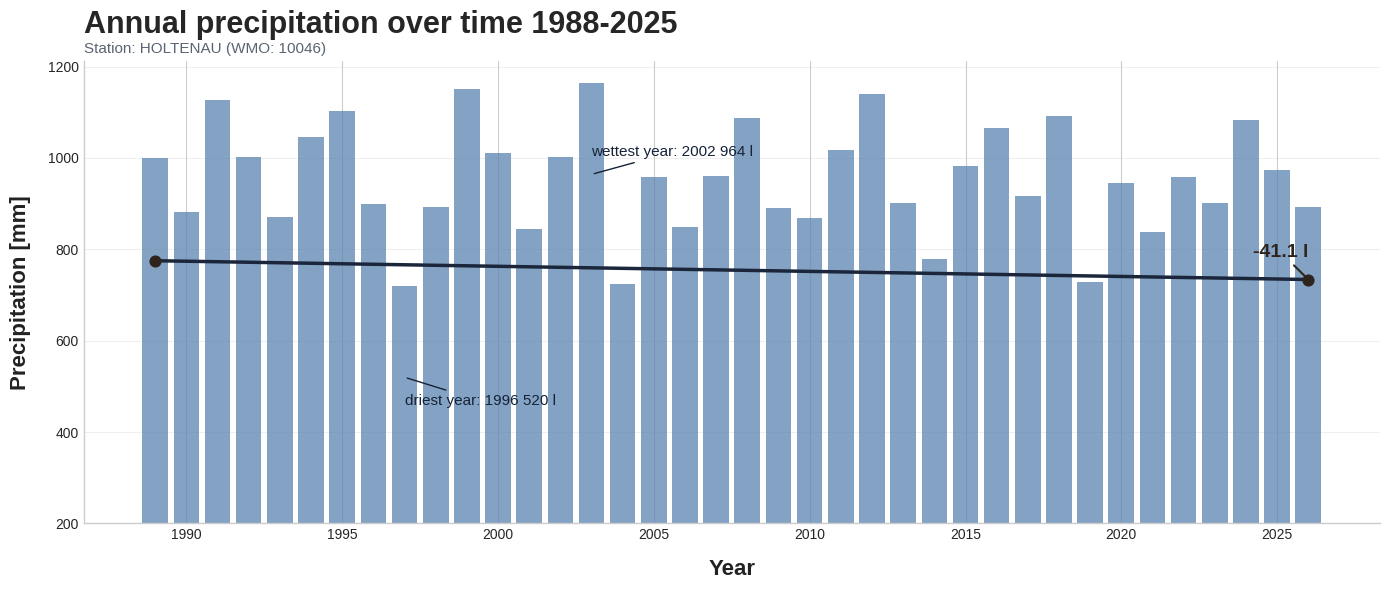

In [ ]:

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(14, 6))

# bottom=200: visual baseline so low-rain years still show readable bars
# width=300: bar width in days (approx. one year on datetime x-axis)
ax.bar(
    to_plot.index,
    to_plot,
    bottom=200,
    color="#5B84B1",
    alpha=0.75,
    width=300,
    edgecolor="none"
)

ax.plot(
    to_plot.index,
    polytempvals,
    color="#1B263B",
    linewidth=2.5
)
ax.scatter(
    [to_plot.index[0], to_plot.index[-1]],
    [polytempvals[0], polytempvals[-1]],
    color='#2F241D',
    s=60,
    zorder=5
)

ax.annotate(
    f"{loss_avg:.1f} mm",
    xy=(to_plot.index[-1], polytempvals[-1]),
    xytext=(to_plot.index[-1], polytempvals[-1]+50),
    fontsize=14,
    fontweight="bold",
    color='#2F241D',
    ha="right",
    arrowprops=dict(
        arrowstyle="-",
        lw=1.5,
        color='#2F241D'
    )
)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", alpha=0.3)

ax.set_title(
    "Annual precipitation over time 1988-2025",
    loc="left",
    pad=20,
    fontsize=22,
    fontweight="bold"
)

ax.set_xlabel(
    "Year",
    fontsize=16,
    fontweight="semibold",
    color="#222222",
    labelpad=12
)

ax.set_ylabel(
    "Precipitation [mm]",
    fontsize=16,
    fontweight="semibold",
    color="#222222",
    labelpad=12
)

ax.text(
    0,                  # x-position (0 = left)
    1.01,               # y-position slightly above axes
    "Station: "+titlestr,
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=11,
    color="#5A6472"
)
ax.annotate(
    "wettest year: "+str(prcp_maxidx.year)+' '+str(prcp_max)+' mm',
    xy=(prcp_maxidx, prcp_max),      # point to annotate
    xytext=(prcp_maxidx, prcp_max + 40),  # text position
    arrowprops=dict(
        arrowstyle="-",
        color="#152238",
        lw=1
    ),
    fontsize=11,
    color="#152238"
)

ax.annotate(
    "driest year: "+str(prcp_minidx.year)+' '+str(prcp_min)+' mm',
    xy=(prcp_minidx, prcp_min),
    xytext=(prcp_minidx, prcp_min - 60),
    arrowprops=dict(
        arrowstyle="-",
        color="#152238",
        lw=1
    ),
    fontsize=11,

    color="#152238"
)
plt.tight_layout()

# Filename: {location}{wmo}prcp.png — same pattern as temperature plot
figfiletitle = location + str(station['wmo'].values[0]) + 'prcp.png'
print(figfiletitle)
plt.savefig(figfiletitle, dpi=300)

## Temperature analysis

Uses daily mean temperature (`tavg`, °C). Trend is a least-squares line over **day index** (0 … n−1), not calendar year; slope × 365 ≈ °C per year.

In [ ]:
datacleartavg = data[data.tavg.notna()]
datatavg = datacleartavg['tavg']

day_idx = np.arange(len(datatavg))  # 0, 1, 2, ... one point per day
poly_temp = np.polyfit(day_idx, datatavg.values, 1)
trend_daily = np.polyval(poly_temp, day_idx)  # used by plot cell below

print('Temperature trend (°C per day, intercept):', poly_temp)
print('Approx. warming per year:', poly_temp[0] * 365, '°C/year')


Temp trend:  [1.43483786e-04 8.62107348e+00]
0.05237158207194383


In [ ]:
# Warming over the plotted period: trend at first vs last day
start_temp = trend_daily[0]
end_temp = trend_daily[-1]
warming = end_temp - start_temp

holtenau10046temp.png


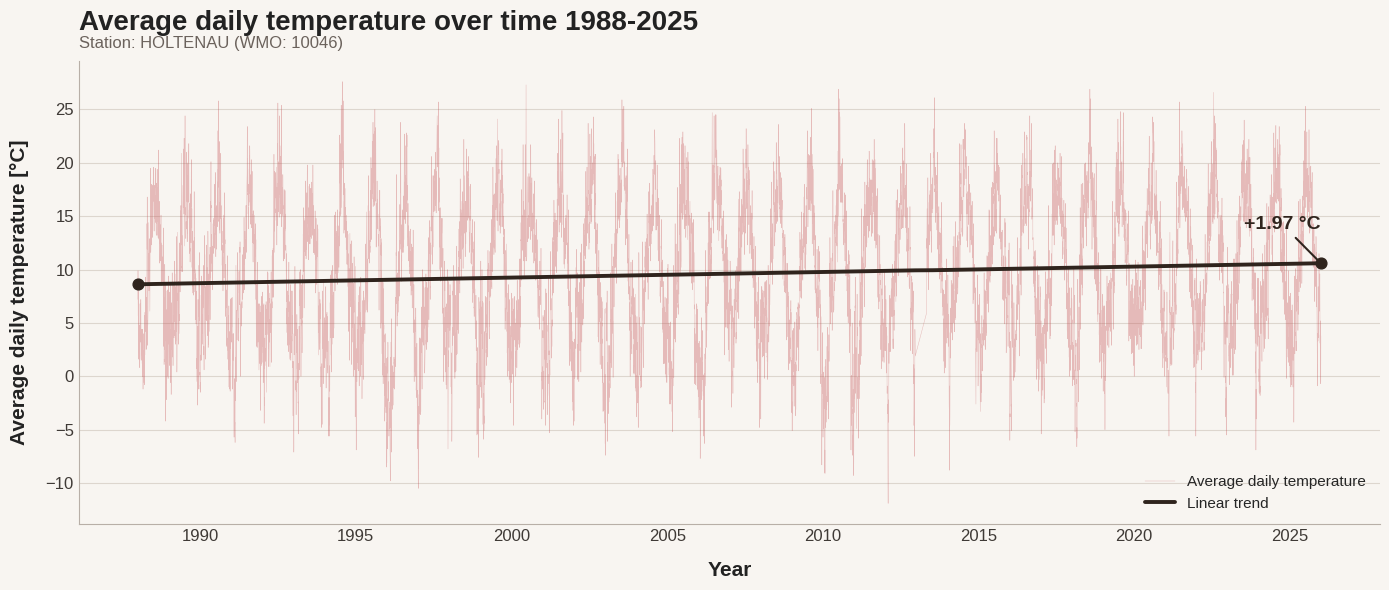

In [ ]:
# Daily series (faint) + linear trend (bold); warming annotation at end of record
fig, ax = plt.subplots(figsize=(14, 6))

# --- colors ---
bg = "#F8F5F1"
daily_color = "#C44E52"      # muted terracotta
trend_color = "#2F241D"      # warm dark brown
grid_color = "#DDD6CE"
text_color = "#222222"
subtle_text = "#6B625C"

fig.patch.set_facecolor(bg)
ax.set_facecolor(bg)

ax.plot(
    datatavg.index,
    datatavg,
    color=daily_color,
    linewidth=0.35,
    alpha=0.35,
    label="Average daily temperature"
)

# trend
ax.plot(
    datatavg.index,
    trend_daily,
    color=trend_color,
    linewidth=2.8,
    label="Linear trend"
)

ax.scatter(
    [datatavg.index[0], datatavg.index[-1]],
    [start_temp, end_temp],
    color=trend_color,
    s=60,
    zorder=5
)

ax.annotate(
    f"+{warming:.2f} °C",
    xy=(datatavg.index[-1], end_temp),
    xytext=(datatavg.index[-1], end_temp + 3.2),
    fontsize=14,
    fontweight="bold",
    color=trend_color,
    ha="right",
    arrowprops=dict(
        arrowstyle="-",
        lw=1.5,
        color=trend_color
    )
)

# title + subtitle
ax.set_title(
    "Average daily temperature over time 1988-2025",
    loc="left",
    fontsize=20,
    fontweight="bold",
    color=text_color,
    pad=22
)

ax.text(
    0,
    1.02,
    "Station: "+titlestr,
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=12,
    color=subtle_text
)

# labels
ax.set_xlabel(
    "Year",
    fontsize=15,
    fontweight="semibold",
    color=text_color,
    labelpad=12
)

ax.set_ylabel(
    "Average daily temperature [°C]",
    fontsize=15,
    fontweight="semibold",
    color=text_color,
    labelpad=12
)

# grid
ax.grid(axis="y", color=grid_color, linewidth=0.8)
ax.grid(axis="x", visible=False)

# spines
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#B8AFA7")
    ax.spines[spine].set_linewidth(0.8)

# ticks
ax.tick_params(axis="both", labelsize=12, colors="#3F3A36")

#ax.xaxis.set_major_locator(mdates.YearLocator(5))
#ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# legend
ax.legend(
    frameon=False,
    fontsize=11,
    loc="lower right"
)

plt.tight_layout()

# Filename: {location}{wmo}temp.png — same pattern as precipitation plot
figfiletitle = location + str(station['wmo'].values[0]) + 'temp.png'
print(figfiletitle)
plt.savefig(figfiletitle, dpi=300)

In [ ]:
# Same warming metric as the plot annotation (for quick numeric check)
print(f'Warming over period: {warming:.2f} °C')
print(datatavg.index[0], '–', datatavg.index[-1])

1.9703193561970753
1988-01-01 00:00:00 2025-12-31 00:00:00


### External comparison

City-level climate explorer for cross-checking patterns: https://fitzlab.shinyapps.io/cityapp/